In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file = pd.read_excel('C:/Data_/excel/data_jobs_salary_all.xlsx',sheet_name='maaz_1')
file['job_posted_month']=pd.to_datetime(file['job_posted_date'])
file['job_posted_month_no']=file['job_posted_month'].dt.month


print(file.info())
                   

<class 'pandas.DataFrame'>
RangeIndex: 32672 entries, 0 to 32671
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        32672 non-null  str           
 1   job_title              32672 non-null  str           
 2   job_location           32317 non-null  str           
 3   job_via                32662 non-null  str           
 4   job_schedule_type      32531 non-null  str           
 5   job_work_from_home     32672 non-null  bool          
 6   search_location        32672 non-null  str           
 7   job_posted_date        32672 non-null  datetime64[us]
 8   job_no_degree_mention  32672 non-null  bool          
 9   job_health_insurance   32672 non-null  bool          
 10  job_country            32672 non-null  str           
 11  salary_rate            32672 non-null  str           
 12  salary_year_avg        22036 non-null  float64       
 13  salary_hour_

In [57]:
import ast

file_da=file[file['job_title_short']=='Data Analyst'].copy()
file['job_skills'] = file_da['job_skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x,str) else x)
file_da=file.reset_index()
file_da=file_da.explode('job_skills')
#file_da_pivot=file_da.pivot_table(index='job_posted_month_no',columns='job_skills',aggfunc='size')
file_da=file_da['job_skills'].dropna().value_counts('job_skills')*1000000
file_da.head()

job_skills
sql        145500.274638
excel      110982.625538
python      79934.086901
tableau     78777.716747
sas         48567.546472
Name: proportion, dtype: float64

<Axes: xlabel='job_posted_month'>

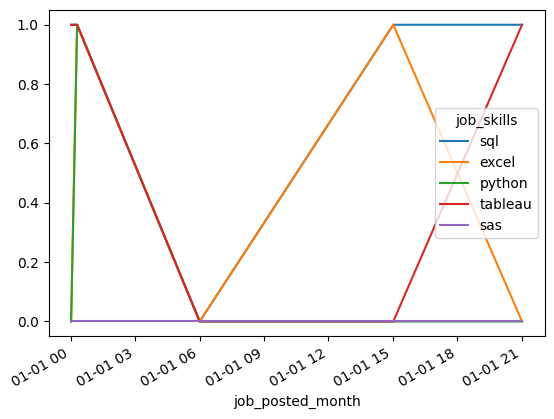

In [66]:
file_dat=file[file['job_title_short']=='Data Analyst'].copy()
file_dat=file_dat.explode('job_skills')
file_dat=file_dat.pivot_table(index='job_posted_month',columns='job_skills',fill_value=0,aggfunc='size')
file_dat.loc['Total']=file_dat.sum()
file_dat.loc['Total'].sort_values(ascending=True).index
file_dat_final=file_dat[file_dat.loc['Total'].sort_values(ascending=False).index]
file_dat_final=file_dat_final.drop(index='Total')
file_dat_final.iloc[:5,:5].plot(kind='line')